In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats as st

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
palette = {'wt': 'blue', 'mutated': 'red', 'heterozygous': 'orange'}


In [3]:
adata = sc.read_h5ad('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_genotyped_adata.h5ad')
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))

adata_gap = adata.copy()

In [4]:
adata = sc.read_h5ad('../output/lhs_genotyped_adata.h5ad')
adata.obsm['genotypes'] = adata.obsm['genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))
adata.obsm['predicted_genotypes'] = adata.obsm['predicted_genotypes'].replace(({0 : 'wt', 1 : 'mutated', 2 : 'heterozygous'}))

adata_dual = adata.copy()

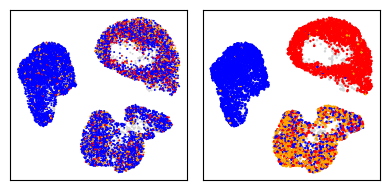

In [5]:
fig, axs = plt.subplots(1,2, figsize=(4, 2))
for i, probe in enumerate(['AKAP9 c.1389G>T']):
    adata.obs['temp'] = adata.obsm['genotypes'][probe].copy()
    BC_to_keep = adata[adata.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata[adata.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[0],
        show=False,
        legend_loc='right margin' if i == 3 else None
    )

    adata_gap.obs['temp'] = adata_gap.obsm['genotypes'][probe].copy()
    BC_to_keep = adata_gap[adata_gap.obs['temp'].notna()].obs['BC'].unique()[0]
    sc.pl.umap(
        adata_gap[adata_gap.obs['BC'] == BC_to_keep].copy(),
        color='temp',
        frameon=True,
        title=probe,
        palette=palette,
        ax=axs[1],
        show=False,
        legend_loc='right margin' if i == 3 else None
    )

    for col in [0,1]:
        axs[col].set_xlabel('')
        axs[col].set_ylabel('')
        axs[col].set_title('')
        
plt.tight_layout()

plt.savefig('../plots/lhs_genotype_umaps.pdf', bbox_inches='tight')


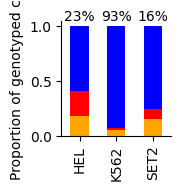

In [6]:
fig, axs = plt.subplots(figsize=(2, 2), sharey=True)
for i, probe in enumerate(['AKAP9 c.1389G>T']):
    adata.obs['temp'] = adata.obsm['genotypes'][probe].copy()
    proportions = adata.obs.groupby('cell_type', observed=False)['temp'].value_counts(normalize=True).unstack().fillna(0)
    if 'mutated' in proportions.columns:
        proportions = proportions.sort_values(['mutated'])
    colors = ['orange', 'red', 'blue']
    expected_columns = ['heterozygous', 'mutated', 'wt']
    available_columns = [col for col in expected_columns if col in proportions.columns]
    proportions = proportions[available_columns]
    proportions = proportions.reindex(labels=['HEL','K562','SET2']).copy()
    colors = [colors[expected_columns.index(col)] for col in available_columns]
    proportions.plot(kind='bar', stacked=True, ax=axs, color=colors)
    axs.set_xlabel('Cell Type')
    axs.set_ylabel('Proportion of genotyped cells')
    axs.get_legend().remove()
    # Add count of cells genotyped above each bar
    for j, cell_type in enumerate(proportions.index):
        count = adata.obs[adata.obs['cell_type'] == cell_type]['temp'].notna().sum()
        total_cells = adata.obs[adata.obs['cell_type'] == cell_type].shape[0]
        proportion_genotyped = count / total_cells
        prop_correct = (adata[(adata.obs['cell_type'] == cell_type) & (adata.obs['temp'].notna())].obsm['genotypes'][probe] == adata[(adata.obs['cell_type'] == cell_type) & (adata.obs['temp'].notna())].obsm['predicted_genotypes'][probe]).value_counts(normalize=True)[True]
        axs.text(j, 1.02, f'{prop_correct:.0%}', ha='center', va='bottom', fontsize=10)
    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    axs.set_xlabel('')
plt.tight_layout()

plt.savefig('../plots/select_variant_proportions_dual_LHS.pdf', bbox_inches='tight')